In [19]:
import os

# Set OMP_NUM_THREADS to 4
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"]="1"

In [20]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy
import geopandas as gpd
from shapely.geometry import Point
import utils
import scipy.stats as stats

In [21]:
import scipy.signal as signal

In [22]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv


%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [23]:
%R Sys.setenv(OMP_NUM_THREADS = 4)
%R Sys.setenv(OPENBLAS_NUM_THREADS = 4)
%R Sys.setenv(MKL_NUM_THREADS = 4)

1


In [24]:
twosamples = importr("twosamples")
extRemes = importr("extRemes")

In [25]:
%R source("R_utils.R")

In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

## Define functions

In [28]:
from scipy.stats import genextreme as gev
def empirical_return_level(data):
    """
    Compute empirical return level using the algorithm introduced in Tutorial 2
    """
    df = pd.DataFrame(index=np.arange(data.size))
    # sort the data
    df["sorted"] = np.sort(data)[::-1]
    # rank via scipy instead to deal with duplicate values
    df["ranks_sp"] = np.sort(stats.rankdata(-data))
    # find exceedence probability
    n = data.size
    df["exceedance"] = df["ranks_sp"] / (n + 1)
    # find return period
    df["period"] = 1 / df["exceedance"]

    df = df[::-1]

    out = xr.DataArray(
        dims=["period"],
        coords={"period": df["period"]},
        data=df["sorted"],
        name="level",
    )
    return out

In [29]:
%%R -w 800 --type=cairo  

extremes_bootL <- function(r_df,n,alpha){

  ntime <- length(r_df[['TXx']])
  boot_rl100 <- matrix(data = NA,nrow=ntime,ncol=n)

  i<-1
  while (i < n){
      index <- 1:ntime
      bx <- sample(index, size = ntime, replace = TRUE)
      r_df['bglost']<- r_df[['glost']][bx]
      r_df['bAFI']<- r_df[['TXx']][bx]
      r_df['btime'] <- r_df[['time']][bx]
      ib <- which(r_df$btime == min(r_df$btime))[1]
      ie <- which(r_df$btime == max(r_df$btime))[1]
      initial_vals <- list(location = mean(r_df$bAFI), scale = sd(r_df$bAFI), shape = 0.1)
      b_fit <- fevd(bAFI, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ bglost)
      if (b_fit$results$convergence==0){
        pp <- summary(b_fit, silent = TRUE)
        AIC <- pp$AIC
        dat <- data.frame(rl100=return.level(b_fit, return.period = c(100)),btime=r_df$btime)
        boot_rl100[,i] <- dat[order(dat$btime),]$rl100
        i <- i+1
      }
    }

  RL_q <- apply(boot_rl100, 1, quantile, probs=c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE) 
  RLdiff_q <- quantile(boot_rl100[ntime,]-boot_rl100[1,], probs =c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE)
  return(list(RL_q=RL_q,RLdiff_q=RLdiff_q))
  }

##########################
 
 extremes_bootLS <- function(r_df,n,alpha){

  ntime <- length(r_df[['TXx']])
  boot_rl100 <- matrix(data = NA,nrow=ntime,ncol=n)

  i<-1
  while (i < n){
      index <- 1:ntime
      bx <- sample(index, size = ntime, replace = TRUE)
      r_df['bglost']<- r_df[['glost']][bx]
      r_df['bAFI']<- r_df[['TXx']][bx]
      r_df['btime'] <- r_df[['time']][bx]
      ib <- which(r_df$btime == min(r_df$btime))[1]
      ie <- which(r_df$btime == max(r_df$btime))[1]
      initial_vals <- list(location = mean(r_df$bAFI), scale = sd(r_df$bAFI), shape = 0.1)
      b_fit <- fevd(bAFI, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ bglost,scale.fun= ~ bglost)
      if (b_fit$results$convergence==0){
        pp <- summary(b_fit, silent = TRUE)
        AIC <- pp$AIC
        dat <- data.frame(rl100=return.level(b_fit, return.period = c(100)),btime=r_df$btime)
        boot_rl100[,i] <- dat[order(dat$btime),]$rl100
        i <- i+1
      }
    }

  RL_q <- apply(boot_rl100, 1, quantile, probs=c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE) 
  RLdiff_q <- quantile(boot_rl100[ntime,]-boot_rl100[1,], probs =c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE)
  return(list(RL_q=RL_q,RLdiff_q=RLdiff_q))
  }
##########################  

extremes_boot_iiLS <- function(r_df,n,alpha,yearb=1941,yeare=2025){

  ntime <- length(r_df[['TXx']])
  boot_rl100 <- matrix(data = NA,nrow=ntime,ncol=n)

  i<-1
  while (i < n){
    index <- 1:ntime
    bx <- sample(index, size = ntime, replace = TRUE)
    r_df['bglost']<- r_df[['glost']][bx]
    r_df['bAFI']<- r_df[['TXx']][bx]
    r_df['btime'] <- r_df[['time']][bx]
    Tib <- which(r_df$btime == yearb)[1]
    Tie <- which(r_df$btime == yeare)[1]
    if (!is.na(Tie) & !is.na(Tib)){
      initial_vals <- list(location = mean(r_df$bAFI), scale = sd(r_df$bAFI), shape = 0.1)
      b_fit <- fevd(bAFI, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ bglost,scale.fun= ~ bglost)
      if (b_fit$results$convergence==0){
        pp <- summary(b_fit, silent = TRUE)
        AIC <- pp$AIC
        dat <- data.frame(rl100=return.level(b_fit, return.period = c(100)),btime=r_df$btime)
        boot_rl100[,i] <- dat[order(dat$btime),]$rl100
        i <- i+1
      }
      }
    }

  RL_q <- apply(boot_rl100, 1, quantile, probs=c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE) 
  RLdiff_q <- quantile(boot_rl100[ntime,]-boot_rl100[1,], probs =c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE)

  return(list(RL_q=RL_q,RLdiff_q=RLdiff_q))
  }

##########################
 
extremes_boot_iiLLS <- function(r_df,n,alpha,yearb=1941,yeare=2025){

  ntime <- length(r_df[['TXx']])
  boot_rl100 <- matrix(data = NA,nrow=ntime,ncol=n)

  i<-1
  while (i < n){
    index <- 1:ntime
    bx <- sample(index, size = ntime, replace = TRUE)
    r_df['bglost']<- r_df[['glost']][bx]
    r_df['bAFI']<- r_df[['TXx']][bx]
    r_df['bPDO']<- r_df[['PDO']][bx]
    r_df['btime'] <- r_df[['time']][bx]
    Tib <- which(r_df$btime == yearb)[1]
    Tie <- which(r_df$btime == yeare)[1]
    if (!is.na(Tie) & !is.na(Tib)){
      initial_vals <- list(location = mean(r_df$bAFI), scale = sd(r_df$bAFI), shape = 0.1)
      b_fit <- fevd(bAFI, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ bglost+bPDO,scale.fun= ~ bglost)
      if (b_fit$results$convergence==0){
        pp <- summary(b_fit, silent = TRUE)
        AIC <- pp$AIC
        dat <- data.frame(rl100=return.level(b_fit, return.period = c(100)),btime=r_df$btime)
        boot_rl100[,i] <- dat[order(dat$btime),]$rl100
        i <- i+1
      }
      }
    }

  RL_q <- apply(boot_rl100, 1, quantile, probs=c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE) 
  RLdiff_q <- quantile(boot_rl100[ntime,]-boot_rl100[1,], probs =c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE)

return(list(RL_q=RL_q,RLdiff_q=RLdiff_q))
  }

##########################  

extremes_bootLLS <- function(r_df,n,alpha){

  ntime <- length(r_df[['TXx']])
  boot_rl100 <- matrix(data = NA,nrow=ntime,ncol=n)

  i<-1
  while (i < n){
      index <- 1:ntime
      bx <- sample(index, size = ntime, replace = TRUE)
      r_df['bglost']<- r_df[['glost']][bx]
      r_df['bPDO']<- r_df[['PDO']][bx]
      r_df['bAFI']<- r_df[['TXx']][bx]
      r_df['btime'] <- r_df[['time']][bx]
      ib <- which(r_df$btime == min(r_df$btime))[1]
      ie <- which(r_df$btime == max(r_df$btime))[1]
      initial_vals <- list(location = mean(r_df$bAFI), scale = sd(r_df$bAFI), shape = 0.1)
      b_fit <- fevd(bAFI, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ bglost+bPDO,scale.fun= ~ bglost)
      if (b_fit$results$convergence==0){
        pp <- summary(b_fit, silent = TRUE)
        AIC <- pp$AIC
        dat <- data.frame(rl100=return.level(b_fit, return.period = c(100)),btime=r_df$btime)
        boot_rl100[,i] <- dat[order(dat$btime),]$rl100
        i <- i+1
      }
    }

  RL_q <- apply(boot_rl100, 1, quantile, probs=c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE) 
  RLdiff_q <- quantile(boot_rl100[ntime,]-boot_rl100[1,], probs =c(alpha/2, 0.5, 1 - alpha/2), na.rm = TRUE)
  return(list(RL_q=RL_q,RLdiff_q=RLdiff_q))
  }

##########################

## Read Files

In [ ]:
yearb=1941
yeare=2025

ifile='/AnnualMaximumDailyTmax.era5.1941.2025.nc4'

dso = xr.open_dataset(ifile)
dso = dso.drop_vars('TXx_day')
dso['time'] = np.arange(1941,2025+1,1)

dso = dso.sel(time=slice(f'{yearb-1}-01-01',f'{yeare}-02-01'))
dso = dso.sortby('lat')

units = 'K'

# K to Farenheit
dso['TXx'] = (dso['TXx'] - 273.15) * 9/5 + 32 
units = f'$\degree$ F'

In [31]:
dsm = xr.open_dataset('/Projects/era5/timeInvariant/lsmask.nc')
dsm = dsm.sortby('lat')
dsm = dsm.isel(time=0, drop=True)
dsm = dsm.sel(lon=dso['lon'],lat=dso['lat'])

dso['TXx'] = dso['TXx'].where(dsm['lsmask']>=0.55)

In [ ]:
fileGLOST = 'annual_LOESS_NOAA_GLOST_anomaly.nc'
ds_glost=xr.open_dataset(fileGLOST)
ds_glost = ds_glost.sel(time=slice(f'{yearb-1}-01-01',f'{yeare}-02-01'))
ann_glost = ds_glost['glost']
dso=dso.merge({'glost':ann_glost})

In [ ]:
pdo_errsstv5_file ='pdo.timeseries.ersstv5.csv'
df=pd.read_csv(pdo_errsstv5_file, encoding= 'unicode_escape')
df.columns = ['time', 'PDO']

dspdo = xr.Dataset.from_dataframe(df.set_index('time'))
dspdo['time']=dspdo['time'].astype('datetime64[ns]')
dspdo = dspdo.sel(time=slice('1854-01-01','2026-01-30'))

In [34]:
fs = 12  
cutoff_years = 10
cutoff_freq = 1 / (cutoff_years)  # 0.1 cycles per year

# 2. Design the Butterworth filter
# order=2 is often sufficient; higher orders are steeper but can be unstable
b, a = signal.butter(N=5, Wn=cutoff_freq, btype='low', fs=fs, analog=False)

# 3. Apply the filter to your data
# 'filtfilt' applies the filter forward and backward to eliminate phase shift
filtered_data = signal.filtfilt(b, a, dspdo['PDO'])
filtered_data =xr.DataArray(filtered_data,dims='time',coords={'time':dspdo.time})
xxx = dspdo['PDO'].sel(time=dspdo.time.dt.month.isin([6,7,8])).groupby('time.year').mean('time')
yyy = filtered_data.sel(time=dspdo.time.dt.month.isin([6,7,8])).groupby('time.year').mean('time')

In [35]:
pdoJJA=dspdo['PDO'].sel(time=dspdo.time.dt.month.isin([6,7,8]))
fs = 3  
cutoff_years = 10
cutoff_freq = 1 / (cutoff_years)  # 0.1 cycles per year

# 2. Design the Butterworth filter
# order=2 is often sufficient; higher orders are steeper but can be unstable
b, a = signal.butter(N=5, Wn=cutoff_freq, btype='low', fs=fs, analog=False)

# 3. Apply the filter to your data
# 'filtfilt' applies the filter forward and backward to eliminate phase shift
filtpdoJJA = signal.filtfilt(b, a, pdoJJA)
filtpdoJJA =xr.DataArray(filtpdoJJA,dims='time',coords={'time':pdoJJA.time})
pdoJJAfilt = filtpdoJJA.groupby('time.year').mean('time')

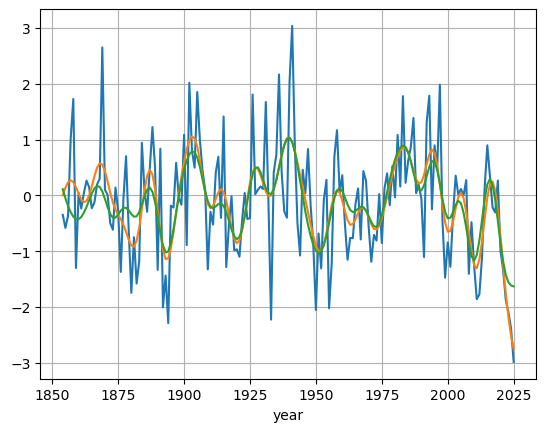

In [36]:
pdoJJA.groupby('time.year').mean('time').plot()
filtpdoJJA.groupby('time.year').mean('time').plot()
yyy.plot()
plt.grid()

blue: PDO.sel(time=dspdo.time.dt.month.isin([6,7,8])).groupby('time.year').mean('time').<br>
green: 10yr low pass filter applied on all months then select only summer month and average for each year.<br>
orange : 10yr low pass filter applied on summer months only and average for each year.<br>

In [ ]:
pdo_errsstv5_file ='pdo.timeseries.ersstv5.csv'
df=pd.read_csv(pdo_errsstv5_file, encoding= 'unicode_escape')
df.columns = ['time', 'PDO']
df=df[(df['time']>=f'{yearb}-01-01')\
        &(df['time']<=f'{yeare+1}-02-01')]
dspdo = xr.Dataset.from_dataframe(df.set_index('time'))
dspdo['time']=dspdo['time'].astype('datetime64[ns]')
pdoJJA = utils.season_JJA(dspdo['PDO'])
pdoJJA = pdoJJA.rename({'year':'time'})
dso=dso.merge({'PDO':pdoJJA})

In [38]:

dso=dso.merge({'PDO':pdoJJA})

In [39]:
lon_min = 190
lon_max = 220
lat_min = 53
lat_max = 72
ds = dso.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
Tlon = ds.lon.data
Tlat = ds.lat.data

In [40]:
ptlon=[213,194.25,209.25,207.,213]                                                                       
ptlat=[61.75,65.25,63.25,61.,63.75]


In [ ]:
yearb=1941
yeare=2025
lon_min = 235
lon_max = 293
lat_min = 25
lat_max = 50
dirin =''

dsj = xr.open_dataset('//era5_TXx_jump_1976.nc')
#dsj = dsj.sel(lon=ds0['lon'],lat=ds0['lat'])
jump = dsj['TXx_jump_1976']

ds0 = xr.open_dataset(f'{dirin}/TXx_Alaska_ij_LocScaglost_extremes_1941_2025.nc')
rl1000 = ds0['rl100'].where(jump.sel(lon=ds0['lon'],lat=ds0['lat'])<3)


ds2 = xr.open_dataset(f'{dirin}/TXx_Alaska_ij_glost_PDO_extremes_1941_2025.nc')
rl1002 = ds2['rl100'].where(jump.sel(lon=ds0['lon'],lat=ds0['lat'])<3)

units = '°F'

Tlabels = ['Loc & scale: time','Loc & scale:time + Loc:PDO']
Trl = [rl1000,rl1002]


## Case Study for point 2 Extremes analysis with different covariantes.

Text(0.5, 1.0, 'TXx RL100 2025: Loc & scale:time + Loc:PDO - Loc & scale: time')

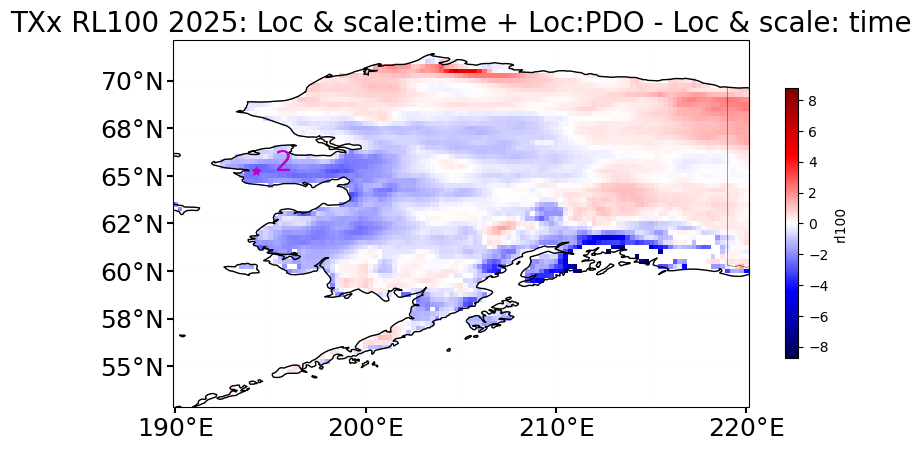

In [42]:
proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(9,9),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.2,left=0.1, right=0.9,top=0.95,hspace=0.01,wspace=0.01)
cc = (Trl[1].sel(time=yeare)-Trl[0].sel(time=yeare)).plot.pcolormesh(ax=ax,cmap='seismic',cbar_kwargs={'shrink':0.4})
for ip in range(1,2):
  ax.scatter(ptlon[ip],ptlat[ip],marker='*',color='m')
  ax.text(ptlon[ip]-360+1,ptlat[ip],f'{ip+1}',color='m',size=20)
####
grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
ax.coastlines()
ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\\degree$E' for ixx in ax.get_xticks()],size=18)
ax.set_yticks(ax.get_yticks()[1:-1],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\\degree$N' for ixx in ax.get_yticks()],size=18)
plt.title(f'TXx RL100 {yeare}: {Tlabels[1]} - {Tlabels[0]}',fontsize=20)

In [43]:
CB_color = ['#377eb8', '#ff7f00', '#4daf4a',
            '#e41a1c', '#a65628', '#984ea3',
            '#f781bf', '#dede00', '#999999']

In [44]:
ij=1
ilon=ptlon[ij]
ilat=ptlat[ij]
# Extract values for boxes
dsij=ds.sel(lon=ilon,lat=ilat)
df = dsij.to_dataframe()
df = df.reset_index()
df= df.assign(cell=1)
# Remove zeros and NAN 
# Remove timeseries with less than 15 data (as in Bilotta et al.)
# Save rows removed
dfsave = df[(df['TXx'].isna())]
df = df[df['TXx'].notna()]

with (ro.default_converter + pandas2ri.converter).context():
      r_df = ro.conversion.get_conversion().py2rpy(df)
globalenv['r_df'] = r_df

# Extremes GEV model fitting  
%R initial_vals <- list(location = mean(r_df[['TXx']]), scale = sd(r_df[['TXx']]), shape = 0.1)
%R m_gevLLpS <- fevd(TXx, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ glost + PDO, scale.fun= ~ glost )
%R m_gevLS <- fevd(TXx, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ glost,scale.fun= ~ glost )
%R m_gevL <- fevd(TXx, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ glost )
%R m_gev <- fevd(TXx, data = r_df,type='GEV',method='MLE', initial = initial_vals)
%R ppLLpS <- summary(m_gevLLpS)
%R ppLS <- summary(m_gevLS)
%R ppL <- summary(m_gevL)
%R pp <- summary(m_gev)
%R rpvalueL <- lr.test(m_gev, m_gevL)$p.value
%R rpvalueS <- lr.test(m_gevL, m_gevLS)$p.value
%R rpvalueLp <- lr.test(m_gevLS, m_gevLLpS)$p.value  
%R -o rpvalueL,rpvalueS,rpvalueLp

## Scores and tests 
%R params <-list(location=findpars(m_gevLLpS)$location,scale=findpars(m_gevLLpS)$scale,shape=findpars(m_gevLLpS)$shape)
%R params['cell'] <- 1
%R tests_scores <- GEV_scores(r_df,params)
%R df_ks_cvmLLpS <- tests_scores$df_ks_cvm
%R SELLpS <- tests_scores$SE
%R DawSebLLpS <- tests_scores$DawSeb
%R CRPSLLpS <- tests_scores$CRPS      
%R -o SELLpS,DawSebLLpS,CRPSLLpS,df_ks_cvmLLpS

%R params <-list(location=findpars(m_gevLS)$location,scale=findpars(m_gevLS)$scale,shape=findpars(m_gevLS)$shape)
%R params['cell'] <- 1
%R tests_scores <- GEV_scores(r_df,params)
%R df_ks_cvmLS <- tests_scores$df_ks_cvm
%R SELS <- tests_scores$SE
%R DawSebLS <- tests_scores$DawSeb
%R CRPSLS <- tests_scores$CRPS      
%R -o SELS,DawSebLS,CRPSLS,df_ks_cvmLS

%R params <-list(location=findpars(m_gevL)$location,scale=findpars(m_gevL)$scale,shape=findpars(m_gevL)$shape)
%R params['cell'] <- 1
%R tests_scores <- GEV_scores(r_df,params)
%R df_ks_cvmL <- tests_scores$df_ks_cvm
%R SEL <- tests_scores$SE
%R DawSebL <- tests_scores$DawSeb
%R CRPSL <- tests_scores$CRPS      
%R -o SEL,DawSebL,CRPSL,df_ks_cvmL

%R params <-list(location=findpars(m_gev)$location,scale=findpars(m_gev)$scale,shape=findpars(m_gev)$shape)
%R params['cell'] <- 1
%R tests_scores <- GEV_scores(r_df,params)
%R df_ks_cvm <- tests_scores$df_ks_cvm
%R SE <- tests_scores$SE
%R DawSeb <- tests_scores$DawSeb
%R CRPS <- tests_scores$CRPS      
%R -o SE,DawSeb,CRPS,df_ks_cvm



fevd(x = TXx, data = r_df, location.fun = ~glost + PDO, scale.fun = ~glost, 
    type = "GEV", method = "MLE", initial = initial_vals)

[1] "Estimation Method used: MLE"


 Negative Log-Likelihood Value:  241.9834 


 Estimated parameters:
       mu0        mu1        mu2     sigma0     sigma1      shape 
69.6139023  4.3730491  0.8786582  4.0229530 -0.3911916 -0.1456871 

 Standard Error Estimates:
       mu0        mu1        mu2     sigma0     sigma1      shape 
0.65895158 1.37389216 0.46250445 0.46898762 0.94275078 0.06217363 

 Estimated parameter covariance matrix.
               mu0          mu1          mu2       sigma0       sigma1
mu0     0.43421718 -0.636281241 -0.050532890  0.014934614  0.035790249
mu1    -0.63628124  1.887579669  0.254466488  0.051845162 -0.199735019
mu2    -0.05053289  0.254466488  0.213910370  0.017670488 -0.091915326
sigma0  0.01493461  0.051845162  0.017670488  0.219949389 -0.326609776
sigma1  0.03579025 -0.199735019 -0.091915326 -0.326609776  0.888779

In [45]:
print(rpvalueL,rpvalueS,rpvalueLp)

[0.01182265] [0.98550731] [0.06515055]


In [46]:
%R alpha<-0.1

array([0.1])

In [47]:
%%R -w 800 --type=cairo

ntime<-nrow(r_df['TXx'])
fitter<-function(data,...,Fit){
        data<-data.frame(TXx=data,Fit$cov.data)
        initial_vals <- list(location = mean(data[['TXx']]), scale = sd(data[['TXx']]), shape = 0.1)
        fit<-fevd(TXx,data=data,type='GEV',method='MLE', initial = initial_vals)
        rl <- return.level(fit, return.period=100)
        out<-c(rl)
        return(out)
    }
simphx<-function(size,...,Fit){
        out<-c(rextRemes(Fit,size))
        return(out)
        }
pbooptedPhx1<-pbooter(x=r_df$TXx,statistic=fitter,B=5000,rmodel=simphx,Fit=m_gev,verbose=TRUE)
res<- ci(pbooptedPhx1,type="perc",alpha=alpha, na.rm = TRUE)

##########################

fitter<-function(data,...,Fit){
        data<-data.frame(TXx=data,Fit$cov.data)
        initial_vals <- list(location = mean(data[['TXx']]), scale = sd(data[['TXx']]), shape = 0.1)
        fit<-fevd(TXx,data=data,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ glost)
        rl <- return.level(fit, return.period=100)
        rldiff <- rl[ntime]-rl[1]
        out<-c(rl,rldiff)
        return(out)
    }
simphx<-function(size,...,Fit){
        out<-c(rextRemes(Fit,size))
        return(out)
        }
pbooptedPhx1<-pbooter(x=r_df$TXx,statistic=fitter,B=5000,rmodel=simphx,Fit=m_gevL,verbose=TRUE)
resL<- ci(pbooptedPhx1,type="perc",alpha=alpha, na.rm = TRUE)

##########################

fitter<-function(data,...,Fit){
        data<-data.frame(TXx=data,Fit$cov.data)
        initial_vals <- list(location = mean(data[['TXx']]), scale = sd(data[['TXx']]), shape = 0.1)
        fit<-fevd(TXx,data=data,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ glost, scale.fun= ~ glost)
        rl <- return.level(fit, return.period=100)
        rldiff <- rl[ntime]-rl[1]
        out<-c(rl,rldiff)
        return(out)
    }
simphx<-function(size,...,Fit){
        out<-c(rextRemes(Fit,size))
        return(out)
        }
pbooptedPhx1<-pbooter(x=r_df$TXx,statistic=fitter,B=5000,rmodel=simphx,Fit=m_gevLS,verbose=TRUE)
resLS<- ci(pbooptedPhx1,type="perc",alpha=alpha, na.rm = TRUE)

##########################

fitter<-function(data,...,Fit){
        data<-data.frame(TXx=data,Fit$cov.data)
        initial_vals <- list(location = mean(data[['TXx']]), scale = sd(data[['TXx']]), shape = 0.1)
        fit<-fevd(TXx,data=data,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ glost + PDO, scale.fun= ~ glost)
        rl <- return.level(fit, return.period=100)
        rldiff <- rl[ntime]-rl[1]
        out<-c(rl,rldiff)
        return(out)
    }
simphx<-function(size,...,Fit){
        out<-c(rextRemes(Fit,size))
        return(out)
        }
pbooptedPhx1<-pbooter(x=r_df$TXx,statistic=fitter,B=5000,rmodel=simphx,Fit=m_gevLLpS,verbose=TRUE)
resLLpS<- ci(pbooptedPhx1,type="perc",alpha=alpha, na.rm = TRUE)

##########################

Simulating data from  simphx 


Simulations found.  Calculating statistic for each simulation.
Bootstrap samples obtained.  Calculating original estimates.
Time difference of 42.79708 secs
Simulating data from  simphx 
Simulations found.  Calculating statistic for each simulation.
Bootstrap samples obtained.  Calculating original estimates.
Time difference of 2.116422 mins
Simulating data from  simphx 
Simulations found.  Calculating statistic for each simulation.
Bootstrap samples obtained.  Calculating original estimates.
Time difference of 2.235468 mins
Simulating data from  simphx 
Simulations found.  Calculating statistic for each simulation.
Bootstrap samples obtained.  Calculating original estimates.
Time difference of 2.394602 mins


In [48]:
%R rl <- cbind(res$perc[1],res$perc[2],res$perc[3])
%R rlL <- cbind(resL$perc[1:85,1],resL$perc[1:85,2],resL$perc[1:85,3])
%R rldiffL <- cbind(resL$perc[86,1],resL$perc[86,2],resL$perc[86,3])
%R rlLS <- cbind(resLS$perc[1:85,1],resLS$perc[1:85,2],resLS$perc[1:85,3])
%R rldiffLS <- cbind(resLS$perc[86,1],resLS$perc[86,2],resLS$perc[86,3])
%R rlLLS <- cbind(resLLpS$perc[1:85,1],resLLpS$perc[1:85,2],resLLpS$perc[1:85,3])
%R rldiffLLS <- cbind(resLLpS$perc[86,1],resLLpS$perc[86,2],resLLpS$perc[86,3])
%R print('ok')

[1] "ok"


array(['ok'], dtype='<U2')

In [49]:
%R -o rl,rlL,rlLS,rlLLS
%R -o rldiffL,rldiffLS,rldiffLLS

In [50]:
%R RL_qLLS <- extremes_bootLLS(r_df,n=5000,alpha=0.1)
%R RL_qLS <- extremes_bootLS(r_df,n=5000,alpha=0.1)
%R print('')

In addition: There were 42 warnings (use warnings() to see them)


[1] ""


array([''], dtype='<U1')

In [51]:
%R RL_qLLSii <- extremes_boot_iiLLS(r_df,n=5000,alpha=0.1,yearb=1941,yeare=2025)
%R RL_qLSii <- extremes_boot_iiLS(r_df,n=5000,alpha=0.1,yearb=1941,yeare=2025)
%R print('')

In addition: Warning messages:
1: In log(z) : NaNs produced
2: In log(z) : NaNs produced
3: In log(z) : NaNs produced
4: In log(z) : NaNs produced


[1] ""


array([''], dtype='<U1')

In [52]:
%R RLdiff_qLLS <- RL_qLLS$RLdiff_q
%R RL_qLLS <- RL_qLLS$RL_q
%R RLdiff_qLS <- RL_qLS$RLdiff_q
%R RL_qLS <- RL_qLS$RL_q
%R RLdiff_qLLSii <- RL_qLLSii$RLdiff_q
%R RL_qLLSii <- RL_qLLSii$RL_q
%R RLdiff_qLSii <- RL_qLSii$RLdiff_q
%R RL_qLSii <- RL_qLSii$RL_q
%R print('ok')

[1] "ok"


array(['ok'], dtype='<U2')

In [53]:
%R -o RL_qLLS,RL_qLS,RL_qLSii,RL_qLLSii
%R -o RLdiff_qLLS,RLdiff_qLS,RLdiff_qLSii,RLdiff_qLLSii

In [54]:

Tquantile=['0.05','0.5','0.95']
dsout=xr.DataArray(rldiffLS[0,:],dims='quantile',coords={'quantile':Tquantile}).to_dataset(name='rldiffLS')
dsout=dsout.merge({'rldiffLLS':xr.DataArray(rldiffLLS[0,:],dims='quantile',coords={'quantile':Tquantile})})
dsout=dsout.merge({'RLdiff_qLS':xr.DataArray(RLdiff_qLS,dims='quantile',coords={'quantile':Tquantile})})
dsout=dsout.merge({'RLdiff_qLLS':xr.DataArray(RLdiff_qLLS,dims='quantile',coords={'quantile':Tquantile})})
dsout=dsout.merge({'RLdiff_qLSii':xr.DataArray(RLdiff_qLSii,dims='quantile',coords={'quantile':Tquantile})})
dsout=dsout.merge({'RLdiff_qLLSii':xr.DataArray(RLdiff_qLLSii,dims='quantile',coords={'quantile':Tquantile})})
df = dsout.to_dataframe()
df = df.transpose()
df[f"95% - 5%"] = df['0.95']-df['0.05']

df['method']=['EG','EG','OS','OS','OS ibie','OS ibie']
df['model']=['Loc & scale: time','Loc & scale:time + Loc:PDO',\
                'Loc & scale: time','Loc & scale:time + Loc:PDO',\
                'Loc & scale: time','Loc & scale:time + Loc:PDO']

Text(0.5, 0.98, 'Return Level CI - line:Estimate, dotted:90% lower & upper CI')

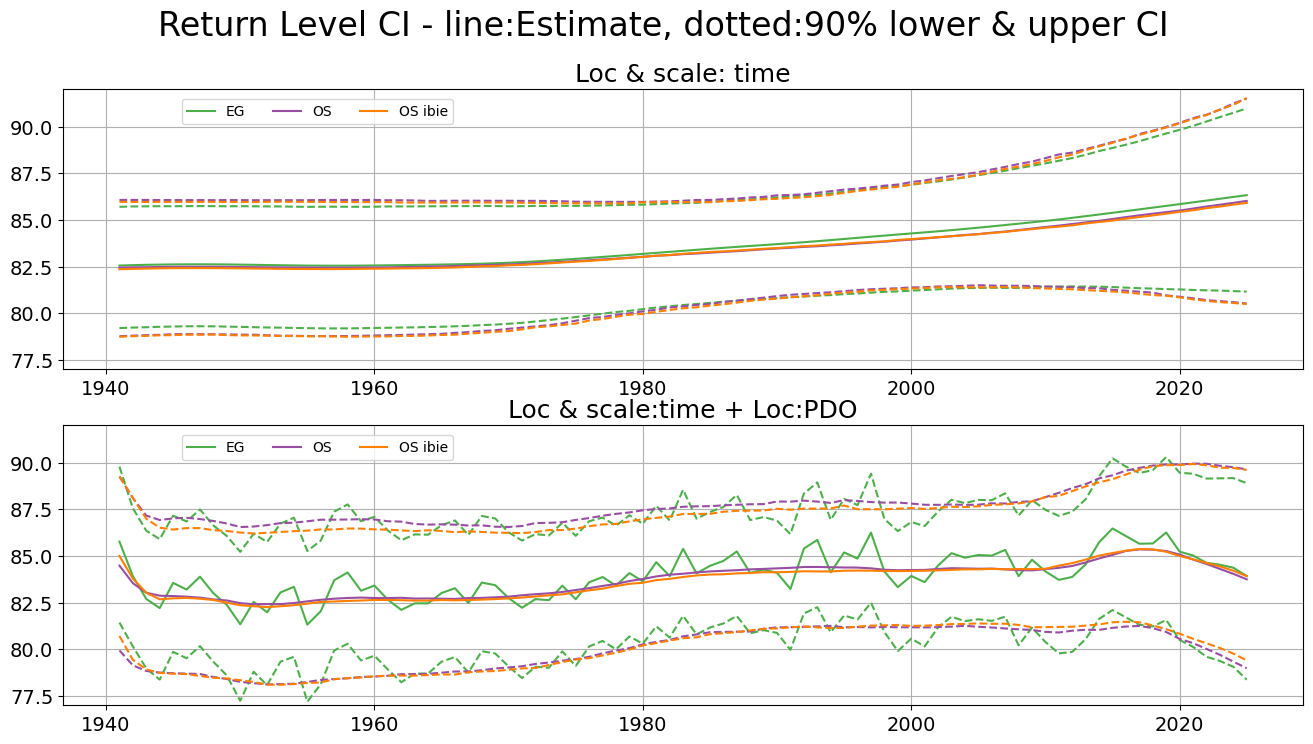

In [55]:
Tlabels=['EG-Stationary','EG-L','EG-LS','EG-LLpS','OS-L','OS-LS','OS-LLpS']
Ttitles='Loc & scale: time','Loc & scale:time + Loc:PDO'
Tlabels=['EG','OS','OS ibie']
Tls = ['--','-','--']
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(16,8))
for iq in [0,2]:

 ax[0].plot(dso.time,rlLS[:,iq],color=CB_color[2],ls=Tls[iq])
 ax[1].plot(dso.time,rlLLS[:,iq],color=CB_color[2],ls=Tls[iq])
 ax[0].plot(dso.time,RL_qLS[iq,:],color=CB_color[5],ls=Tls[iq])
 ax[1].plot(dso.time,RL_qLLS[iq,:],color=CB_color[5],ls=Tls[iq])
 ax[0].plot(dso.time,RL_qLSii[iq,:],color=CB_color[1],ls=Tls[iq])
 ax[1].plot(dso.time,RL_qLLSii[iq,:],color=CB_color[1],ls=Tls[iq])
iq=1 

ax[0].plot(dso.time,rlLS[:,iq],color=CB_color[2],ls=Tls[iq],label=Tlabels[0])
ax[1].plot(dso.time,rlLLS[:,iq],color=CB_color[2],ls=Tls[iq],label=Tlabels[0])
ax[0].plot(dso.time,RL_qLS[iq,:],color=CB_color[5],ls=Tls[iq],label=Tlabels[1])
ax[1].plot(dso.time,RL_qLLS[iq,:],color=CB_color[5],ls=Tls[iq],label=Tlabels[1])
ax[0].plot(dso.time,RL_qLSii[iq,:],color=CB_color[1],ls=Tls[iq],label=Tlabels[2])
ax[1].plot(dso.time,RL_qLLSii[iq,:],color=CB_color[1],ls=Tls[iq],label=Tlabels[2])
for ix in range(0,len(ax)):
  ax[ix].grid()
  ax[ix].set_ylim(77,92)
  ax[ix].set_title(f'{Ttitles[ix]}',fontsize=18)
  ax[ix].legend(loc='upper left',ncol=3,bbox_to_anchor=(0.09,0.99)) 
  ax[ix].tick_params(axis='both', labelsize=14)
plt.suptitle(f"Return Level CI - line:Estimate, dotted:90% lower & upper CI",fontsize=24)

EG : Following E. Gilleland, 2020: a regular bootstrap procedure, but parametric resampling from the fitted GEV distribution function. <br>
OS : Regular bootstrap procedure. <br>
OS ibie : Regular bootstrap procedure but with the first and last year present in the resampling. <br>
<br>
top plot: GEV: ~ location : glost & ~ scale : glost<br>
bottom plot : GEV: ~ location : glost + JJA PDO & ~ scale : glost<br>

Text(0.5, 0.98, 'Return Level CI : 90% upper - lower')

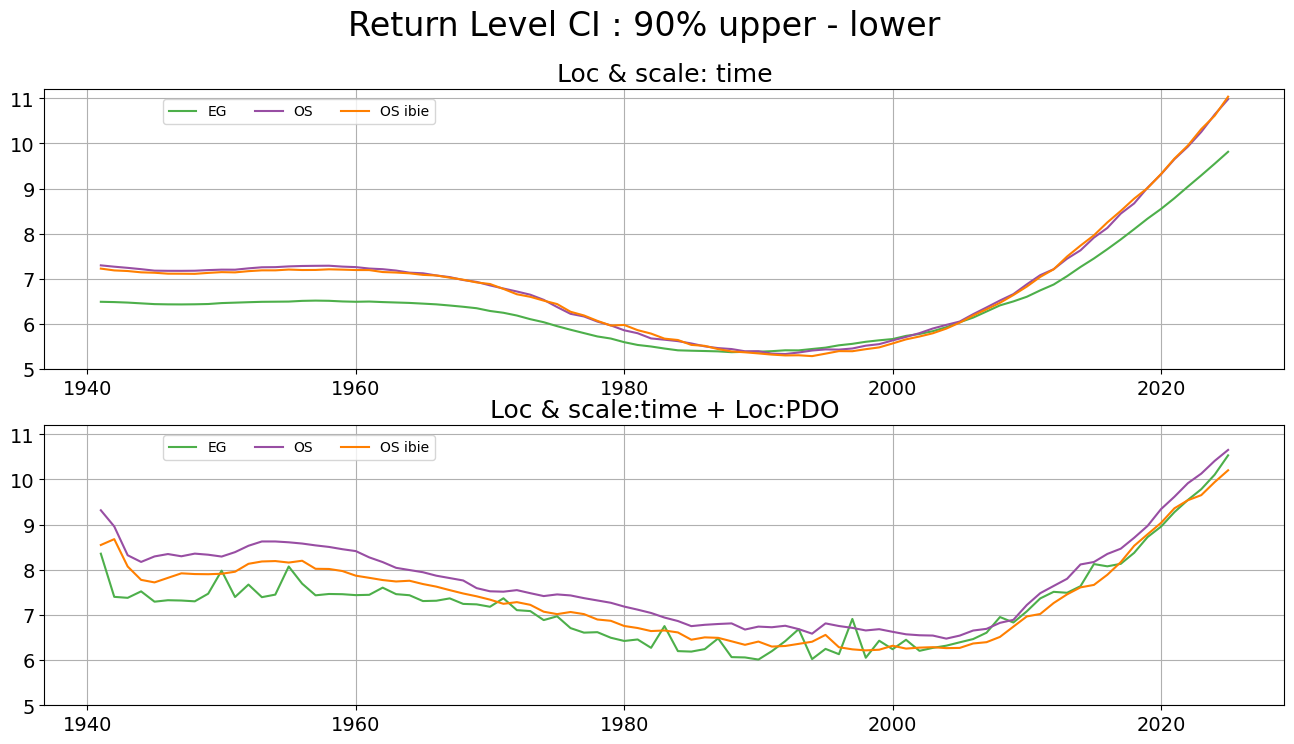

In [ ]:
Tlabels=['EG-Stationary','EG-L','EG-LS','EG-LLpS','OS-L','OS-LS','OS-LLpS']
Ttitles=['Loc & scale: time','Loc & scale:time + Loc:PDO']
Tlabels=['EG','OS','OS ibie']
Tls = ['--','-','--']
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(16,8))
ax[0].plot(dso.time,(rlLS[:,2]-rlLS[:,0]),color=CB_color[2],ls=Tls[iq],label=Tlabels[0])
ax[0].plot(dso.time,(RL_qLS[2,:]-RL_qLS[0,:]),color=CB_color[5],ls=Tls[iq],label=Tlabels[1])
ax[0].plot(dso.time,(RL_qLSii[2,:]-RL_qLSii[0,:]),color=CB_color[1],ls=Tls[iq],label=Tlabels[2])
ax[1].plot(dso.time,(rlLLS[:,2]-rlLLS[:,0]),color=CB_color[2],ls=Tls[iq],label=Tlabels[0])
ax[1].plot(dso.time,(RL_qLLS[2,:]-RL_qLLS[0,:]),color=CB_color[5],ls=Tls[iq],label=Tlabels[1])
ax[1].plot(dso.time,(RL_qLLSii[2,:]-RL_qLLSii[0,:]),color=CB_color[1],ls=Tls[iq],label=Tlabels[2])
for ix in range(0,len(ax)):
  ax[ix].grid()
  ax[ix].set_ylim(5,11.2)
  ax[ix].set_title(f'{Ttitles[ix]}',fontsize=18)
  ax[ix].legend(loc='upper left',ncol=3,bbox_to_anchor=(0.09,0.99)) 
  ax[ix].tick_params(axis='both', labelsize=14)
plt.suptitle(f"Return Level CI : 90% upper - lower",fontsize=24)

EG : Following E. Gilleland, 2020: a regular bootstrap procedure, but parametric resampling from the fitted GEV distribution function. <br>
OS : Regular bootstrap procedure. <br>
OS ibie : Regular bootstrap procedure but with the first and last year present in the resampling. <br>
<br>
top plot: GEV: ~ location : glost & ~ scale : glost<br>
bottom plot : GEV: ~ location : glost + JJA PDO & ~ scale : glost<br>

In [57]:
table = pd.pivot_table(df,  index=['model','method'])
table_style = table.style
styled_table = table_style.format('{:.2f}')
styled_table

Table for RL diff (2025-1941) for the different methods and GEV models.<br>
<br>
EG : Following E. Gilleland, 2020: a regular bootstrap procedure, but parametric resampling from the fitted GEV distribution function. <br>
OS : Regular bootstrap procedure. <br>
OS ibie : Regular bootstrap procedure but with the first and last year present in the resampling. <br>

'Loc & scale: time' : GEV: ~ location : glost & ~ scale : glost<br>
'Loc & scale:time + Loc:PDO' : GEV: ~ location : glost + JJA PDO & ~ scale : glost<br>

In [58]:
KSpvalue = xr.DataArray([df_ks_cvm['KS_pvalue'][-1],df_ks_cvmL['KS_pvalue'][-1],df_ks_cvmLS['KS_pvalue'][-1],df_ks_cvmLLpS['KS_pvalue'][-1]],dims=['models'])
CVMpvalue = xr.DataArray([df_ks_cvm['CVM_pvalue'][-1],df_ks_cvmL['CVM_pvalue'][-1],df_ks_cvmLS['CVM_pvalue'][-1],df_ks_cvmLLpS['CVM_pvalue'][-1]],dims=['models'])
meanCRPS = xr.DataArray([CRPS.mean()[-1],CRPSL.mean()[-1],CRPSLS.mean()[-1],CRPSLLpS.mean()[-1]],dims=['models'])
meanSE = xr.DataArray([SE.mean()[-1],SEL.mean()[-1],SELS.mean()[-1],SELLpS.mean()[-1]],dims=['models'])
meanDawSeb = xr.DataArray([DawSeb.mean()[-1],DawSebL.mean()[-1],DawSebLS.mean()[-1],DawSebLLpS.mean()[-1]],dims=['models'])
dsout = KSpvalue.to_dataset(name='KS')
dsout = dsout.merge({'CVM':CVMpvalue})
dsout = dsout.merge({'CRPS':meanCRPS})
dsout = dsout.merge({'SE':meanSE})
dsout = dsout.merge({'DawSeb':meanDawSeb})
dsout['models']=['S','L','LS','LLpS']
df = dsout.to_dataframe()
df = df.transpose()
df['diagnostic'] = ['KS pvalue','CVM pvalue','CRPS','SE','DawSeb']
table = pd.pivot_table(df,  index=['diagnostic'])
table_style = table.style
styled_table = table_style.format('{:.2f}')
styled_table

models,L,LLpS,LS,S
diagnostic,,,,
CRPS,2.39,2.35,2.39,2.49
CVM pvalue,0.49,0.91,0.15,0.82
DawSeb,3.92,3.90,3.92,3.99
KS pvalue,0.60,0.94,0.14,0.85
SE,18.51,18.14,18.51,19.91


Table for the different tests and GEV models.<br>
<br>
S : Stationary GEV<br>
L : GEV: ~ location : glost <br>
LS : GEV: ~ location : glost & ~ scale : glost<br>
LLpS : GEV: ~ location : glost + JJA PDO & ~ scale : glost<br>

<br>